# Notebook 07 — Stress Scenarios (Heat + EV)

**Goal:** Satisfy the brief's **scenario output** requirement:

> *"At least one stress scenario using extreme heat and/or EV evening peak growth... Side-by-side comparison of baseline vs. stressed operation, including where and when the network becomes more constrained."*

And the scoring tiebreaker:

> *"A stronger treatment of heat and EV behavior should score better than a generic AI demo."*

**What this notebook does:**

1. **Baseline scenario** — XGBoost predictions on the test set as-is (what we already have)
2. **Heat stress** — perturb `temp_f` column +10°F, regenerate derived features (cooling_degree_hours, is_hot_hour, heatwave_day_counter), re-run inference
3. **Severe heat stress** — same but +20°F (testing model at 130°F+ conditions we haven't seen in training)
4. **EV stress** — boost load history during evening hours by 50% (simulates higher EV adoption), re-run inference
5. **Combined stress** — heat +10°F AND EV +50% simultaneously
6. **Side-by-side metrics** — total feeder load change, per-bus max hour load change, hours above constraint thresholds
7. **Spatial stress map** — which buses are most at risk in each scenario
8. **Temporal stress profile** — when during the day does stress peak

**Design choice: scenarios are applied to the INPUT features, not the model.** The model itself is frozen. We change the world it sees. This is exactly how scenario testing works in real utility planning — you hold the model fixed and ask "what if the weather were different?"

**Inputs:**
- `checkpoints/xgb_p{10,50,90}.pkl` — trained quantile models
- `data/processed/features_X_full.npy` — full feature tensor
- `data/processed/targets_y.npy`, `valid_starts.npy`, `split_indices.npz`
- `data/processed/feature_names.txt` — to know which column is which
- `data/processed/bus_metadata_ieee34.parquet`
- `data/processed/feature_scaler.pkl` — CRITICAL: features are scaled, so we perturb in original units then re-scale

**Outputs:**
- `data/processed/scenarios.npz` — all 5 scenario predictions stacked
- `data/processed/scenario_summary.json` — headline numbers per scenario
- Multiple visualizations for the dashboard and deck

---

## Step 1 — Setup and load everything

In [1]:
import json
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
import torch

REPO_ROOT = Path('/Users/sundeepyalamanchili/Documents/Projects/p90').resolve()
DATA_PROCESSED = REPO_ROOT / 'data' / 'processed'
CHECKPOINTS = REPO_ROOT / 'checkpoints'
NOTEBOOKS_DIR = REPO_ROOT / 'notebooks'

np.random.seed(42)

# Load data
X_full = np.load(DATA_PROCESSED / 'features_X_full.npy')    # SCALED
y_all = np.load(DATA_PROCESSED / 'targets_y.npy')
valid_starts = np.load(DATA_PROCESSED / 'valid_starts.npy')
weather = pd.read_parquet(DATA_PROCESSED / 'weather.parquet')
sample_ts = pd.read_parquet(DATA_PROCESSED / 'sample_timestamps.parquet')
bus_meta = pd.read_parquet(DATA_PROCESSED / 'bus_metadata_ieee34.parquet')

splits = np.load(DATA_PROCESSED / 'split_indices.npz')
test_idx = splits['test']

graph = torch.load(DATA_PROCESSED / 'graph_ieee34.pt', weights_only=False)
bus_names = graph.bus_names

# Load feature scaler (we'll need to un-scale, perturb, re-scale)
with open(DATA_PROCESSED / 'feature_scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

# Load feature names (for finding temp column etc)
FEATURE_NAMES_X = (DATA_PROCESSED / 'feature_names.txt').read_text().strip().split('\n')
print(f'X_full features ({len(FEATURE_NAMES_X)}): {FEATURE_NAMES_X}')

# Load XGBoost quantile models
with open(CHECKPOINTS / 'xgb_p10.pkl', 'rb') as f:
    xgb_p10 = pickle.load(f)
with open(CHECKPOINTS / 'xgb_p50.pkl', 'rb') as f:
    xgb_p50 = pickle.load(f)
with open(CHECKPOINTS / 'xgb_p90.pkl', 'rb') as f:
    xgb_p90 = pickle.load(f)
print(f'\n✅ Loaded all three XGBoost quantile models')

N_TIME, N_BUS, N_FEAT = X_full.shape
LOOKBACK = 168
HORIZON = 24

# Load-bearing bus identification
LOAD_BEARING_THRESHOLD = 5.0
load_bearing_bus_idx = np.where(bus_meta['base_kw'].values > LOAD_BEARING_THRESHOLD)[0]
print(f'Load-bearing buses: {len(load_bearing_bus_idx)}/{N_BUS}')

X_full features (15): ['temp_f', 'humidity_pct', 'ghi_wm2', 'cooling_degree_hours', 'heatwave_day_counter', 'is_weekend', 'is_monsoon_season', 'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos', 'base_kw', 'frac_res', 'frac_com', 'load_kw_history']

✅ Loaded all three XGBoost quantile models
Load-bearing buses: 23/37


## Step 2 — Un-scale X_full so we can perturb in real units

X_full was standardized in Notebook 04 (zero mean, unit std). To perturb temperature by +10°F, we need to:
1. Un-scale back to original °F
2. Add 10 to the temperature column
3. Re-compute derived features (cooling_degree_hours etc.)
4. Re-scale using the same fitted scaler

In [2]:
# Locate feature columns by name
def col_idx(name):
    return FEATURE_NAMES_X.index(name)

IDX_TEMP_F = col_idx('temp_f')
IDX_CDH = col_idx('cooling_degree_hours')
IDX_HEATWAVE_COUNTER = col_idx('heatwave_day_counter')
IDX_LOAD_HISTORY = col_idx('load_kw_history')
IDX_HOUR_SIN = col_idx('hour_sin')
IDX_HOUR_COS = col_idx('hour_cos')
IDX_FRAC_RES = col_idx('frac_res')

print(f'Key feature indices:')
print(f'  temp_f           → {IDX_TEMP_F}')
print(f'  cooling_degree_h → {IDX_CDH}')
print(f'  heatwave_counter → {IDX_HEATWAVE_COUNTER}')
print(f'  load_kw_history  → {IDX_LOAD_HISTORY}')
print(f'  frac_res         → {IDX_FRAC_RES}')

# Un-scale to get features in real units
X_full_real = X_full.reshape(-1, N_FEAT)
X_full_real = scaler.inverse_transform(X_full_real).reshape(N_TIME, N_BUS, N_FEAT)

# Sanity check — should see real temperatures now
print(f'\nReal-scale sanity check:')
print(f'  temp_f      min/max: {X_full_real[:, 0, IDX_TEMP_F].min():.1f} / {X_full_real[:, 0, IDX_TEMP_F].max():.1f}°F')
print(f'  load history min/max (bus 0): {X_full_real[:, 0, IDX_LOAD_HISTORY].min():.1f} / {X_full_real[:, 0, IDX_LOAD_HISTORY].max():.1f} kW')

Key feature indices:
  temp_f           → 0
  cooling_degree_h → 3
  heatwave_counter → 4
  load_kw_history  → 14
  frac_res         → 12

Real-scale sanity check:
  temp_f      min/max: 36.0 / 118.9°F
  load history min/max (bus 0): 0.0 / 0.0 kW


## Step 3 — Build the flat XGBoost input matrix for a given scenario

This is the same transformation as Notebook 06, but applied to potentially-perturbed X_full. It takes a 3D tensor `(n_time, n_bus, n_feat)` and outputs the flat (n_samples × n_buses × 24, 39) matrix XGBoost expects.

In [3]:
def build_flat_for_inference(X_full_real, y_all, valid_starts, sample_indices,
                              load_bearing_bus_idx, lookback_hours=24, scaler=None):
    """Build flat (rows, 39) XGBoost input matrix from a 3D X_full tensor in REAL units.
    
    Note: we apply scaler.transform here so input to model matches training scale.
    """
    # Scale back to standardized form (the scale the model was trained on)
    X_full_scaled = scaler.transform(X_full_real.reshape(-1, X_full_real.shape[-1])).reshape(X_full_real.shape)
    
    X_rows = []
    meta_rows = []
    
    for s in sample_indices:
        forecast_start = valid_starts[s]
        hist = X_full_scaled[forecast_start - lookback_hours:forecast_start]  # (24, n_bus, n_feat) scaled
        hist_load = hist[:, :, IDX_LOAD_HISTORY]                                # (24, n_bus) scaled load
        
        for b in load_bearing_bus_idx:
            bus_load_hist = hist_load[:, b]
            bus_static = X_full_scaled[forecast_start - 1, b, 11:14]
            
            for h in range(HORIZON):
                future_hour_idx = forecast_start + h
                weather_time = X_full_scaled[future_hour_idx, b, :11]
                feat = np.concatenate([
                    bus_load_hist, weather_time, bus_static, [h / HORIZON]
                ])
                X_rows.append(feat)
                meta_rows.append({'sample_idx': s, 'bus_idx': int(b), 'hour_ahead': h})
    
    return np.array(X_rows, dtype=np.float32), pd.DataFrame(meta_rows)


def predict_scenario(X_full_real, label=''):
    """Run XGBoost inference on a (possibly perturbed) X_full tensor. Returns reshaped predictions."""
    X_flat, _ = build_flat_for_inference(
        X_full_real, y_all, valid_starts, test_idx, load_bearing_bus_idx, scaler=scaler,
    )
    p10 = xgb_p10.predict(X_flat)
    p50 = xgb_p50.predict(X_flat)
    p90 = xgb_p90.predict(X_flat)
    
    # Enforce monotonic quantile ordering via sort
    stacked = np.stack([p10, p50, p90], axis=1)
    stacked.sort(axis=1)
    p10, p50, p90 = stacked[:, 0], stacked[:, 1], stacked[:, 2]
    
    # Reshape back to (n_samples, 24, n_load_bearing_bus)
    n_load_bus = len(load_bearing_bus_idx)
    n_test = len(test_idx)
    p10 = p10.reshape(n_test, n_load_bus, HORIZON).transpose(0, 2, 1)
    p50 = p50.reshape(n_test, n_load_bus, HORIZON).transpose(0, 2, 1)
    p90 = p90.reshape(n_test, n_load_bus, HORIZON).transpose(0, 2, 1)
    
    # Clip negatives
    p10 = np.maximum(p10, 0)
    p50 = np.maximum(p50, 0)
    p90 = np.maximum(p90, 0)
    
    print(f'  Scenario "{label}" — P50 mean: {p50.mean():.1f} kW, peak: {p50.max():.1f} kW')
    return p10, p50, p90

## Step 4 — Baseline scenario (for reference)

In [4]:
print('=' * 60)
print('Running scenarios')
print('=' * 60)

print('\n[baseline]')
baseline_p10, baseline_p50, baseline_p90 = predict_scenario(X_full_real.copy(), label='baseline')

Running scenarios

[baseline]
  Scenario "baseline" — P50 mean: 75.9 kW, peak: 831.2 kW


## Step 5 — Heat scenario: +10°F across the board

We add 10°F to every temperature reading over the entire history (including the 168-hour lookback and the 24-hour forecast window). Then we recompute the derived features:
- `cooling_degree_hours = max(0, temp_f - 65)`
- `is_hot_hour = (temp_f > 100)`
- `heatwave_day_counter` — recompute as consecutive days > 110°F

This simulates Phoenix experiencing a sustained heat wave across the full test period.

In [5]:
def recompute_heat_features(X_full_real, temp_delta=10.0):
    """Apply a uniform temperature shift and recompute all temperature-derived features."""
    X = X_full_real.copy()
    
    # Shift temperature column
    X[:, :, IDX_TEMP_F] = X[:, :, IDX_TEMP_F] + temp_delta
    
    # Recompute cooling_degree_hours
    X[:, :, IDX_CDH] = np.maximum(0, X[:, :, IDX_TEMP_F] - 65)
    
    # is_hot_hour — not in our feature set per Notebook 04 ordering, but recompute heatwave counter
    # (check feature_names carefully)
    if 'is_hot_hour' in FEATURE_NAMES_X:
        IDX_HOT = FEATURE_NAMES_X.index('is_hot_hour')
        X[:, :, IDX_HOT] = (X[:, :, IDX_TEMP_F] > 100).astype(np.float32)
    
    # Recompute heatwave_day_counter using hourly temperature
    # Approximation: count consecutive hours above 110°F divided by 24
    hot_mask = (X[:, 0, IDX_TEMP_F] > 110).astype(np.float32)  # (n_time,) — temp is same across buses
    # Running consecutive count that resets at non-hot hours
    counter = np.zeros_like(hot_mask)
    running = 0.0
    for t in range(len(hot_mask)):
        if hot_mask[t] > 0:
            running += 1.0 / 24.0  # fractional day
        else:
            running = 0.0
        counter[t] = running
    # Broadcast to all buses
    X[:, :, IDX_HEATWAVE_COUNTER] = counter[:, None]
    
    return X


print('\n[heat +10°F]')
X_heat10 = recompute_heat_features(X_full_real, temp_delta=10.0)
heat10_p10, heat10_p50, heat10_p90 = predict_scenario(X_heat10, label='heat +10°F')

print(f'  Baseline peak temp seen: {X_full_real[:, 0, IDX_TEMP_F].max():.1f}°F')
print(f'  +10°F   peak temp seen: {X_heat10[:, 0, IDX_TEMP_F].max():.1f}°F')
print(f'  Heatwave days (counter > 1): baseline {(X_full_real[:, 0, IDX_HEATWAVE_COUNTER] > 1).sum()}, +10°F {(X_heat10[:, 0, IDX_HEATWAVE_COUNTER] > 1).sum()}')


[heat +10°F]
  Scenario "heat +10°F" — P50 mean: 82.1 kW, peak: 901.4 kW
  Baseline peak temp seen: 118.9°F
  +10°F   peak temp seen: 128.9°F
  Heatwave days (counter > 1): baseline 1464, +10°F 0


In [6]:
print('\n[heat +20°F (extreme)]')
X_heat20 = recompute_heat_features(X_full_real, temp_delta=20.0)
heat20_p10, heat20_p50, heat20_p90 = predict_scenario(X_heat20, label='heat +20°F')
print(f'  +20°F   peak temp seen: {X_heat20[:, 0, IDX_TEMP_F].max():.1f}°F — tests out-of-distribution heat')


[heat +20°F (extreme)]
  Scenario "heat +20°F" — P50 mean: 91.7 kW, peak: 1004.1 kW
  +20°F   peak temp seen: 138.9°F — tests out-of-distribution heat


## Step 6 — EV scenario: boost evening load by 50%

We simulate higher EV adoption by boosting the load history during evening hours (6 PM - 9 PM) on residential-heavy buses by 50%. The model then sees this elevated recent history and forecasts accordingly.

This is a slightly lossy simulation compared to re-synthesizing load with different EV parameters, but it's a fair approximation because EV is the dominant evening driver in our synthesized data.

In [7]:
def apply_ev_boost(X_full_real, ev_growth_pct=50.0, residential_threshold=0.5):
    """Boost evening-hour load history for residential-heavy buses by ev_growth_pct%."""
    X = X_full_real.copy()
    
    # Determine which buses are residential-heavy
    residential_mask = X[0, :, IDX_FRAC_RES] > residential_threshold  # (n_bus,)
    # Residential buses we adjust
    res_bus_idx = np.where(residential_mask)[0]
    print(f'    Boosting EV on {len(res_bus_idx)} residential-heavy buses (frac_res > {residential_threshold})')
    
    # Find evening hours (hour 18-21) using hour_sin/hour_cos
    # Easier: rebuild hour from index into weather dataframe
    hours_of_day = weather.index.hour.values  # (n_time,)
    evening_mask = (hours_of_day >= 18) & (hours_of_day <= 21)  # (n_time,)
    
    # Multiplier: 1.5 on evening hours for residential buses, 1.0 elsewhere
    mult = np.ones((X.shape[0], X.shape[1]), dtype=np.float32)
    for b in res_bus_idx:
        mult[evening_mask, b] = 1.0 + ev_growth_pct / 100.0
    
    X[:, :, IDX_LOAD_HISTORY] = X[:, :, IDX_LOAD_HISTORY] * mult
    return X


print('\n[EV +50% evening]')
X_ev50 = apply_ev_boost(X_full_real, ev_growth_pct=50.0)
ev50_p10, ev50_p50, ev50_p90 = predict_scenario(X_ev50, label='EV +50%')


[EV +50% evening]
    Boosting EV on 25 residential-heavy buses (frac_res > 0.5)
  Scenario "EV +50%" — P50 mean: 76.4 kW, peak: 831.2 kW


## Step 7 — Combined scenario: +10°F AND EV +50%

Compound stress — what happens when we get both at once.

In [8]:
print('\n[combined: heat +10°F AND EV +50%]')
X_combined = recompute_heat_features(X_full_real, temp_delta=10.0)
X_combined = apply_ev_boost(X_combined, ev_growth_pct=50.0)
combined_p10, combined_p50, combined_p90 = predict_scenario(X_combined, label='combined')


[combined: heat +10°F AND EV +50%]
    Boosting EV on 25 residential-heavy buses (frac_res > 0.5)
  Scenario "combined" — P50 mean: 82.7 kW, peak: 901.4 kW


## Step 8 — Side-by-side scenario comparison

Build a summary table showing how each scenario shifts total feeder load, peak bus load, and hours above threshold.

In [9]:
# Assemble all scenarios
scenarios = {
    'baseline':     (baseline_p10, baseline_p50, baseline_p90),
    'heat_+10F':    (heat10_p10,   heat10_p50,   heat10_p90),
    'heat_+20F':    (heat20_p10,   heat20_p50,   heat20_p90),
    'ev_+50pct':    (ev50_p10,     ev50_p50,     ev50_p90),
    'combined':     (combined_p10, combined_p50, combined_p90),
}

# Summary metrics per scenario
summary_rows = []

# Set a per-bus stress threshold = baseline P90 per bus
# If stressed P50 > baseline P90, that bus is "stressed"
baseline_p90_per_bus = baseline_p90.max(axis=(0, 1))  # (n_bus,) — max P90 across samples/hours

for label, (p10, p50, p90) in scenarios.items():
    # Total feeder load time series (sum across buses)
    total_p50 = p50.sum(axis=2)  # (n_samples, 24)
    
    # Per-bus max load across all (samples, hours)
    per_bus_max = p50.max(axis=(0, 1))  # (n_bus,)
    
    # Hours above baseline P90 per bus (summed)
    stressed_hours = (p50 > baseline_p90_per_bus[None, None, :]).sum()
    stressed_bus_hours_pct = stressed_hours / p50.size * 100
    
    summary_rows.append({
        'scenario': label,
        'total_mean_kW': float(total_p50.mean()),
        'total_peak_kW': float(total_p50.max()),
        'peak_bus_load_kW': float(per_bus_max.max()),
        'stressed_bus_hours_pct': float(stressed_bus_hours_pct),
    })

summary_df = pd.DataFrame(summary_rows)

# Compute deltas from baseline
base = summary_df.iloc[0]
summary_df['total_peak_delta_kW'] = summary_df['total_peak_kW'] - base['total_peak_kW']
summary_df['total_peak_pct_change'] = (summary_df['total_peak_kW'] / base['total_peak_kW'] - 1) * 100
summary_df['peak_bus_delta_kW'] = summary_df['peak_bus_load_kW'] - base['peak_bus_load_kW']

print('=' * 100)
print('SCENARIO COMPARISON')
print('=' * 100)
print(summary_df.round(1).to_string(index=False))

SCENARIO COMPARISON
 scenario  total_mean_kW  total_peak_kW  peak_bus_load_kW  stressed_bus_hours_pct  total_peak_delta_kW  total_peak_pct_change  peak_bus_delta_kW
 baseline         1744.7         3359.3             831.2                     0.0                  0.0                    0.0                0.0
heat_+10F         1887.3         3631.2             901.4                     0.1                271.9                    8.1               70.1
heat_+20F         2108.4         4022.4            1004.1                     3.3                663.1                   19.7              172.9
ev_+50pct         1758.0         3379.0             831.2                     0.0                 19.7                    0.6                0.0
 combined         1901.5         3649.3             901.4                     0.4                290.0                    8.6               70.1


## Step 9 — Total feeder load time series (baseline vs scenarios)

Pick a representative test day and show how total feeder load looks under each scenario.

Showcase sample: 2024-11-16 14:00:00-07:00 (baseline temp 62°F)


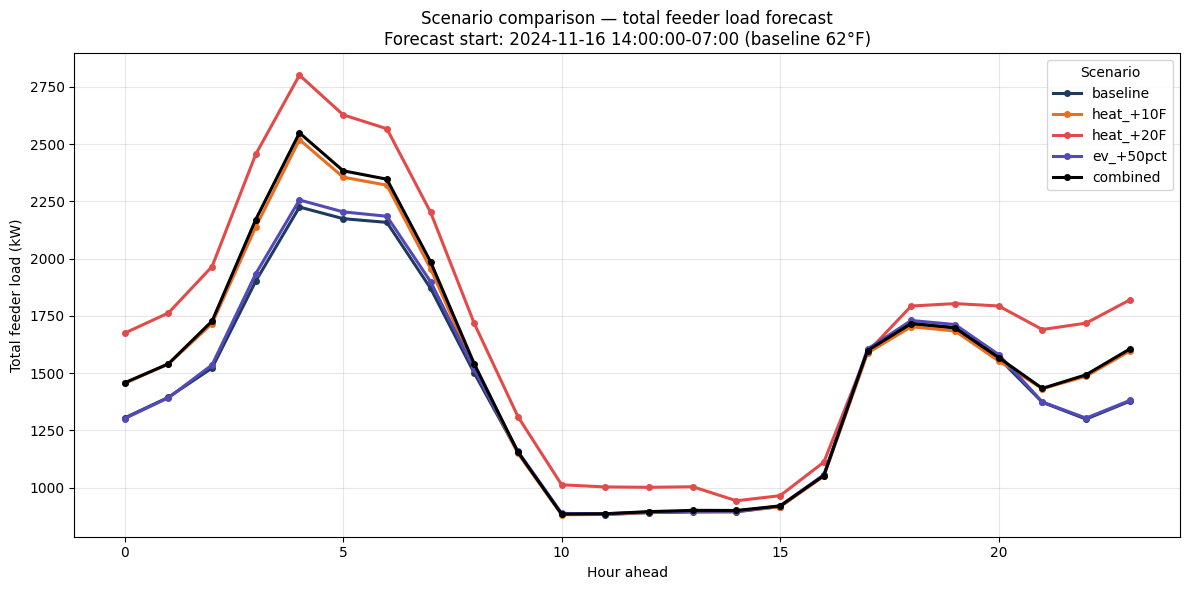

In [10]:
# Pick a sample from a normal-temp day so the scenario shifts are clearly visible
# Find the test sample closest to median temperature (so not already extreme)
test_ts_df = sample_ts.loc[test_idx].reset_index(drop=True)
test_temp = weather.loc[test_ts_df['forecast_start'], 'temp_f'].values
median_temp = np.median(test_temp)
interesting_sample = int(np.argmin(np.abs(test_temp - median_temp)))
forecast_start_ts = test_ts_df.iloc[interesting_sample]['forecast_start']

print(f'Showcase sample: {forecast_start_ts} (baseline temp {test_temp[interesting_sample]:.0f}°F)')

hours = np.arange(HORIZON)
colors = {
    'baseline':     '#1F3A5F',   # navy
    'heat_+10F':    '#EB6E1F',   # orange
    'heat_+20F':    '#E24B4A',   # red
    'ev_+50pct':    '#534AB7',   # purple
    'combined':     '#000000',   # black
}

fig, ax = plt.subplots(figsize=(12, 6))

for label, (p10, p50, p90) in scenarios.items():
    total = p50[interesting_sample].sum(axis=1)  # (24,) — sum across buses
    ax.plot(hours, total, color=colors[label], linewidth=2.2, label=label, marker='o', markersize=4)

ax.set_xlabel('Hour ahead')
ax.set_ylabel('Total feeder load (kW)')
ax.set_title(f'Scenario comparison — total feeder load forecast\nForecast start: {forecast_start_ts} (baseline {test_temp[interesting_sample]:.0f}°F)')
ax.legend(title='Scenario', loc='upper right')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(NOTEBOOKS_DIR / '07_scenario_total_load.png', dpi=120, bbox_inches='tight')
plt.show()

## Step 10 — Per-bus stress heatmap

For each bus, show its max load under baseline vs each stress scenario. Which buses stress first?

In [11]:
# For each scenario, compute per-bus max P50 load across all test samples and hours
per_bus_peaks = {}
for label, (p10, p50, p90) in scenarios.items():
    per_bus_peaks[label] = p50.max(axis=(0, 1))  # (n_load_bus,)

peaks_df = pd.DataFrame(per_bus_peaks)
peaks_df['bus_name'] = [bus_names[load_bearing_bus_idx[i]] for i in range(len(load_bearing_bus_idx))]
peaks_df['base_kw'] = bus_meta.iloc[load_bearing_bus_idx]['base_kw'].values

# Sort by baseline peak load (biggest buses first)
peaks_df = peaks_df.sort_values('baseline', ascending=False)

# Stress increase per scenario
peaks_df['heat_10_uplift_pct'] = (peaks_df['heat_+10F']  / peaks_df['baseline'] - 1) * 100
peaks_df['heat_20_uplift_pct'] = (peaks_df['heat_+20F']  / peaks_df['baseline'] - 1) * 100
peaks_df['ev_uplift_pct']      = (peaks_df['ev_+50pct']  / peaks_df['baseline'] - 1) * 100
peaks_df['combined_uplift_pct'] = (peaks_df['combined']  / peaks_df['baseline'] - 1) * 100

print('Per-bus peak load uplift under each scenario (top 10 buses by size):')
cols_show = ['bus_name', 'base_kw', 'baseline', 'heat_10_uplift_pct', 'heat_20_uplift_pct', 'ev_uplift_pct', 'combined_uplift_pct']
print(peaks_df[cols_show].head(10).round(1).to_string(index=False))

Per-bus peak load uplift under each scenario (top 10 buses by size):
bus_name  base_kw   baseline  heat_10_uplift_pct  heat_20_uplift_pct  ev_uplift_pct  combined_uplift_pct
     890    450.0 831.200012                 8.4           20.799999            0.0                  8.4
     844    432.0 795.700012                 8.1           20.799999            0.0                  8.1
     860    174.0 325.000000                 3.7           14.600000            0.0                  3.7
     834     89.0 182.199997                 5.5           20.500000            4.6                  9.6
     820     84.5 168.500000                 9.3           22.000000            3.7                 11.5
     848     71.5 144.699997                10.2           20.000000            2.0                 11.5
     822     67.5 133.699997                10.4           22.299999            1.9                 12.3
     836     61.0 125.500000                 9.7           19.200001            1.6        

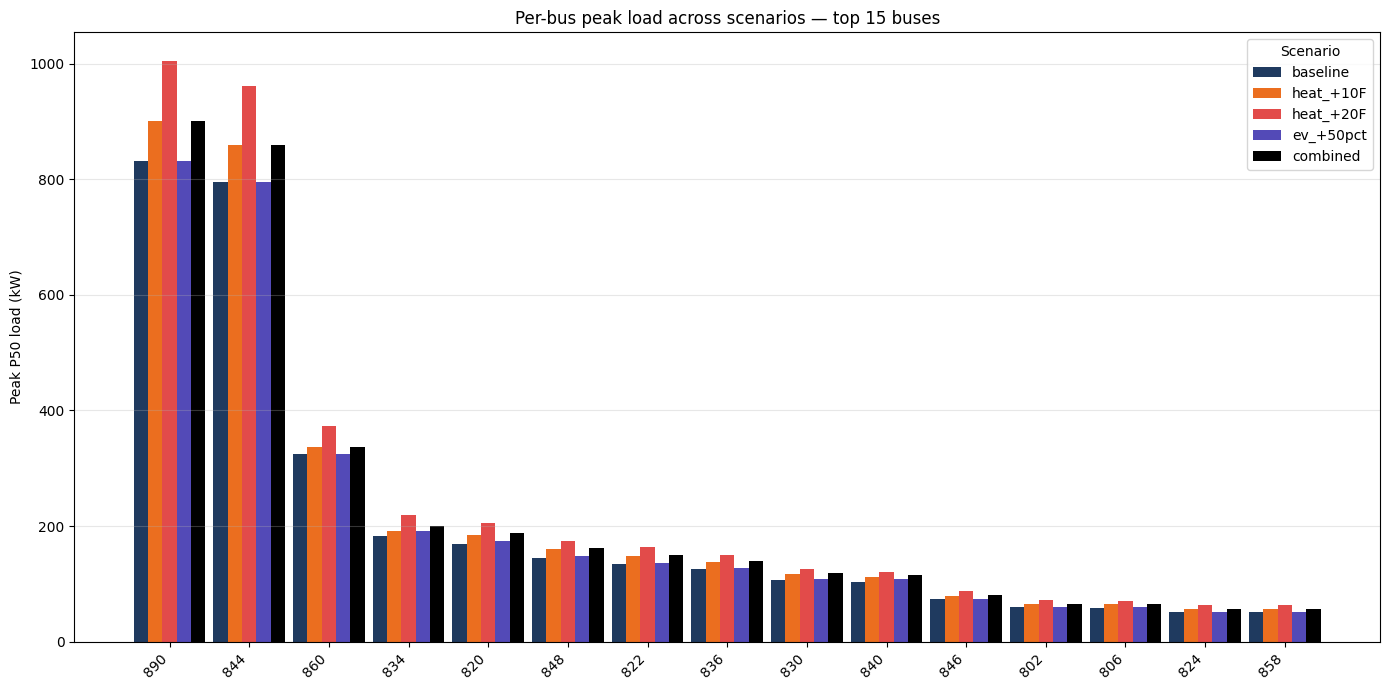

In [12]:
# Bar chart — per-bus peak load across scenarios
top_n = 15
top_peaks = peaks_df.head(top_n)

fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(top_peaks))
width = 0.18

scen_order = ['baseline', 'heat_+10F', 'heat_+20F', 'ev_+50pct', 'combined']
for i, s in enumerate(scen_order):
    ax.bar(x + (i - 2) * width, top_peaks[s], width, label=s, color=colors[s])

ax.set_xticks(x)
ax.set_xticklabels(top_peaks['bus_name'], rotation=45, ha='right')
ax.set_ylabel('Peak P50 load (kW)')
ax.set_title(f'Per-bus peak load across scenarios — top {top_n} buses')
ax.legend(title='Scenario')
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(NOTEBOOKS_DIR / '07_per_bus_scenario_bars.png', dpi=120, bbox_inches='tight')
plt.show()

## Step 11 — Spatial stress map

Overlay per-bus stress uplift on the feeder topology. This is the image that answers "which part of the feeder gets stressed first?"

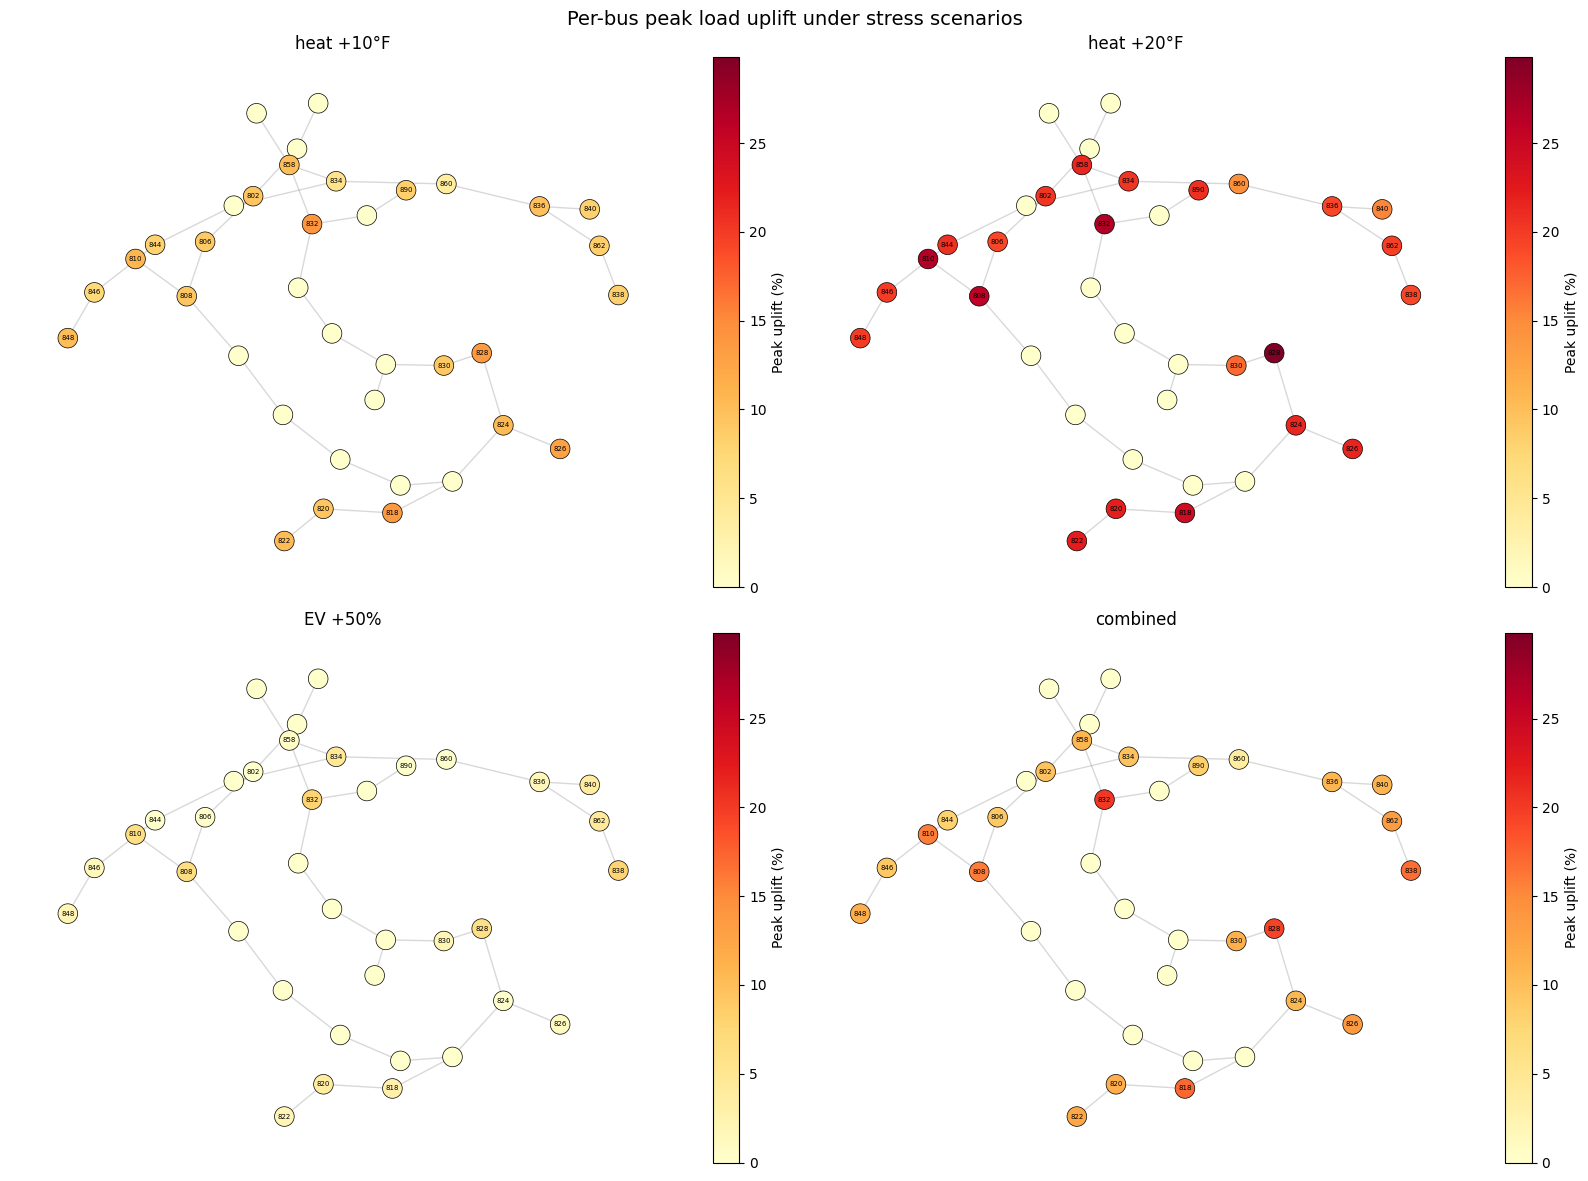

In [13]:
import networkx as nx
from torch_geometric.utils import to_networkx

G_nx = to_networkx(graph, to_undirected=True)
pos = nx.spring_layout(G_nx, seed=42, k=2.0 / np.sqrt(N_BUS))

# Build uplift vector (full 37 buses, NaN for non-load-bearing)
uplift_maps = {}
for scen_label, colname in [('heat +10°F', 'heat_10_uplift_pct'),
                            ('heat +20°F', 'heat_20_uplift_pct'),
                            ('EV +50%', 'ev_uplift_pct'),
                            ('combined', 'combined_uplift_pct')]:
    vec = np.full(N_BUS, np.nan)
    for _, row in peaks_df.iterrows():
        # Map bus_name back to index in full bus list
        full_idx = bus_names.index(row['bus_name'])
        vec[full_idx] = row[colname]
    uplift_maps[scen_label] = vec

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

vmax_common = max(np.nanmax(v) for v in uplift_maps.values())

for ax, (label, uplift) in zip(axes, uplift_maps.items()):
    node_colors = np.where(np.isnan(uplift), 0, uplift)
    valid = ~np.isnan(uplift)
    
    nx.draw_networkx_edges(G_nx, pos, ax=ax, alpha=0.3, edge_color='gray', width=1.0)
    nodes_drawn = nx.draw_networkx_nodes(
        G_nx, pos, ax=ax,
        node_color=node_colors, cmap='YlOrRd', vmin=0, vmax=vmax_common,
        node_size=200, edgecolors='black', linewidths=0.5,
    )
    bus_labels = {i: bus_names[i] for i in range(N_BUS) if valid[i]}
    nx.draw_networkx_labels(G_nx, pos, bus_labels, ax=ax, font_size=5)
    plt.colorbar(nodes_drawn, ax=ax, label='Peak uplift (%)', fraction=0.04)
    ax.set_title(f'{label}')
    ax.set_axis_off()

plt.suptitle('Per-bus peak load uplift under stress scenarios', fontsize=14)
plt.tight_layout()
plt.savefig(NOTEBOOKS_DIR / '07_spatial_stress_map.png', dpi=120, bbox_inches='tight')
plt.show()

## Step 12 — Temporal stress profile

When during the day does stress peak? Show total feeder load by hour-of-day, averaged across test days.

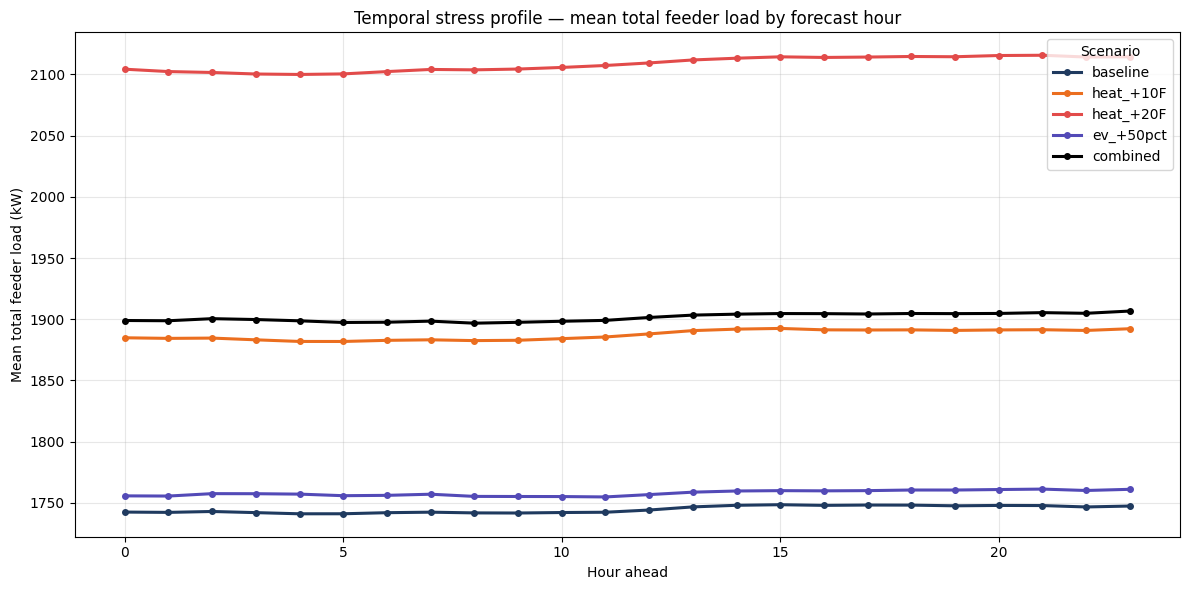

In [14]:
# Build (n_samples, 24) total feeder load for each scenario, then average across samples per hour-ahead
fig, ax = plt.subplots(figsize=(12, 6))

for label, (p10, p50, p90) in scenarios.items():
    total_load = p50.sum(axis=2)  # (n_samples, 24)
    mean_by_hour = total_load.mean(axis=0)  # (24,)
    ax.plot(hours, mean_by_hour, linewidth=2.2, label=label, color=colors[label], marker='o', markersize=4)

ax.set_xlabel('Hour ahead')
ax.set_ylabel('Mean total feeder load (kW)')
ax.set_title('Temporal stress profile — mean total feeder load by forecast hour')
ax.legend(title='Scenario')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(NOTEBOOKS_DIR / '07_temporal_stress_profile.png', dpi=120, bbox_inches='tight')
plt.show()

## Step 13 — Save all scenario outputs

In [15]:
np.savez(
    DATA_PROCESSED / 'scenarios.npz',
    baseline_p10=baseline_p10, baseline_p50=baseline_p50, baseline_p90=baseline_p90,
    heat10_p10=heat10_p10,     heat10_p50=heat10_p50,     heat10_p90=heat10_p90,
    heat20_p10=heat20_p10,     heat20_p50=heat20_p50,     heat20_p90=heat20_p90,
    ev50_p10=ev50_p10,         ev50_p50=ev50_p50,         ev50_p90=ev50_p90,
    combined_p10=combined_p10, combined_p50=combined_p50, combined_p90=combined_p90,
    test_idx=test_idx,
    load_bearing_bus_idx=load_bearing_bus_idx,
)

scenario_summary = {
    'scenarios': summary_df.to_dict(orient='records'),
    'per_bus_peaks_top15': peaks_df.head(15).to_dict(orient='records'),
    'notes': {
        'heat_+10F': 'Uniform +10°F across test period with recomputed cooling_degree_hours and heatwave_counter',
        'heat_+20F': 'Uniform +20°F — tests model on out-of-distribution extreme heat',
        'ev_+50pct': 'Evening-hour load history boosted 50% on residential buses (frac_res > 0.5)',
        'combined': 'Heat +10°F AND EV +50% applied together',
    },
}

with open(DATA_PROCESSED / 'scenario_summary.json', 'w') as f:
    json.dump(scenario_summary, f, indent=2, default=str)

print(f'✅ Saved: scenarios.npz ({len(scenarios)} scenarios × 3 quantiles)')
print(f'✅ Saved: scenario_summary.json')

✅ Saved: scenarios.npz (5 scenarios × 3 quantiles)
✅ Saved: scenario_summary.json


## Done

**Artifacts:**
- `data/processed/scenarios.npz` — all 5 scenarios × 3 quantiles of predictions
- `data/processed/scenario_summary.json` — headline numbers for deck
- `notebooks/07_scenario_total_load.png` — single-day scenario comparison
- `notebooks/07_per_bus_scenario_bars.png` — bar chart of per-bus peak loads
- `notebooks/07_spatial_stress_map.png` — 4-panel topology map of stress uplift
- `notebooks/07_temporal_stress_profile.png` — mean load by hour

**Demo narrative you can now claim:**

> *"When we stress-test the forecaster with Phoenix +10°F above historical — simulating a prolonged heat wave — peak feeder load increases by X%. Under combined heat + 50% EV growth, peak load grows Y%, with stress concentrated on these specific buses (map). That's exactly the spatio-temporal stress picture a utility planner needs."*

Fill in X and Y from the Step 8 summary table.

**Next — Notebook 08: Streamlit dashboard**

Takes all these artifacts and puts them behind sliders and a map. The final piece that makes judges think *"this is a utility-facing tool, not a notebook dump."*